# The radio will not wait for your FFT

A fast FFT is not enough for a live signal path. Each I/Q block has a deadline:

```text
block period = samples per block / incoming samples per second
```

If processing takes longer, the queue grows until the receiver drops data. This notebook builds the same small DSP chain used in the Ramwise study, verifies the CPU and GPU answers, then reads the published capacity and paced-arrival evidence.

The saved outputs were produced on the study machine. You can rerun the CPU path anywhere; the GPU cells skip cleanly when CuPy or CUDA is unavailable.

In [1]:
from pathlib import Path
import platform
import warnings
import statistics
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import fft as scipy_fft
from scipy import signal as scipy_signal

RESULTS = Path("results")
print(f"Python {platform.python_version()}")
print(f"NumPy {np.__version__}; SciPy {__import__('scipy').__version__}; pandas {pd.__version__}")

Python 3.12.13
NumPy 2.4.6; SciPy 1.16.3; pandas 3.0.5


## One block, one deadline

The deterministic complex64 replay includes FIR history so the 129-tap filter can return one complete block. Each block is split into non-overlapping 2,048-sample frames, windowed, transformed, converted to power, and checked with a peak-to-mean detector.

The detector is intentionally simple. Its job is to make the FFT feed a complete decision path rather than terminate at an array that no application consumes.

In [2]:
BLOCK_SIZE = 32_768
FFT_SIZE = 2_048
FIR_TAPS = 129
THRESHOLD = 40.0
OVERLAP = FIR_TAPS - 1

taps = scipy_signal.firwin(FIR_TAPS, 0.35, window="hamming", fs=2.0).astype(np.float32)
window = scipy_signal.windows.hann(FFT_SIZE, sym=False).astype(np.float32)

def make_iq_block(index: int, tone_present: bool) -> np.ndarray:
    count = BLOCK_SIZE + OVERLAP
    rng = np.random.default_rng(20260814 + index * 7919)
    noise = (
        rng.standard_normal(count, dtype=np.float32)
        + 1j * rng.standard_normal(count, dtype=np.float32)
    ) * np.float32(0.08)
    if not tone_present:
        return np.asarray(noise, dtype=np.complex64)
    start = index * BLOCK_SIZE - OVERLAP
    sample = np.arange(start, start + count, dtype=np.float32)
    carrier = np.exp(2j * np.pi * np.float32(0.083) * sample).astype(np.complex64)
    side = np.exp(-2j * np.pi * np.float32(0.137) * sample).astype(np.complex64)
    return np.asarray(noise + np.float32(1.5) * carrier + np.float32(0.12) * side)

def summarize_power(power, module):
    peak_bins = module.argmax(power, axis=1).astype(module.int32)
    peak = module.max(power, axis=1)
    mean = module.mean(power, axis=1)
    ratio = peak / module.maximum(mean, module.float32(1e-20))
    return peak_bins, ratio.astype(module.float32), (ratio > module.float32(THRESHOLD)).astype(module.uint8)

def cpu_process(block: np.ndarray):
    filtered = scipy_signal.fftconvolve(block, taps, mode="valid")
    frames = filtered[:BLOCK_SIZE].reshape(-1, FFT_SIZE)
    spectrum = scipy_fft.fft(frames * window, axis=1, workers=8, overwrite_x=True)
    power = spectrum.real * spectrum.real + spectrum.imag * spectrum.imag
    return summarize_power(power, np)

tone = make_iq_block(0, True)
noise = make_iq_block(1, False)
cpu_tone = cpu_process(tone)
cpu_noise = cpu_process(noise)

print(f"Tone detections: {int(cpu_tone[2].sum())}/{BLOCK_SIZE // FFT_SIZE}")
print(f"Noise detections: {int(cpu_noise[2].sum())}/{BLOCK_SIZE // FFT_SIZE}")
print(f"Detected tone bin: {int(cpu_tone[0][0])}")

Tone detections: 16/16
Noise detections: 0/16
Detected tone bin: 170


## The CuPy path

The archived cuSignal project moved its maintained signal-processing work into `cupyx.scipy.signal`. The GPU version below therefore uses CuPy's current SciPy-compatible signal module and FFT interface.

In [3]:
GPU_AVAILABLE = False
try:
    warnings.filterwarnings("ignore", category=FutureWarning, module="cupyx.jit")
    import cupy as cp
    from cupyx.scipy import signal as cupy_signal

    taps_gpu = cp.asarray(taps)
    window_gpu = cp.asarray(window)

    def gpu_process(block: np.ndarray):
        device_block = cp.asarray(block)
        filtered = cupy_signal.fftconvolve(device_block, taps_gpu, mode="valid")
        frames = filtered[:BLOCK_SIZE].reshape(-1, FFT_SIZE)
        spectrum = cp.fft.fft(frames * window_gpu, axis=1)
        power = spectrum.real * spectrum.real + spectrum.imag * spectrum.imag
        bins, ratios, detected = summarize_power(power, cp)
        result = tuple(cp.asnumpy(item) for item in (bins, ratios, detected))
        cp.cuda.Stream.null.synchronize()
        return result

    gpu_tone = gpu_process(tone)
    np.testing.assert_array_equal(cpu_tone[0], gpu_tone[0])
    np.testing.assert_array_equal(cpu_tone[2], gpu_tone[2])
    np.testing.assert_allclose(cpu_tone[1], gpu_tone[1], rtol=5e-3, atol=5e-3)

    properties = cp.cuda.runtime.getDeviceProperties(0)
    device_name = properties.get("name", properties.get(b"name", "unknown"))
    if isinstance(device_name, bytes):
        device_name = device_name.decode()
    GPU_AVAILABLE = True
    print(f"CuPy {cp.__version__}; GPU: {device_name}")
    print("GPU output matches the SciPy reference")
except Exception as error:
    print(f"GPU path skipped: {type(error).__name__}: {error}")

CuPy 14.1.1; GPU: NVIDIA RTX PRO 4000 Blackwell SFF Edition
GPU output matches the SciPy reference


## A small local timing is a demonstration, not the study

This call starts with pageable NumPy input and ends with host-visible detector arrays. It includes transfer and synchronization. The publication matrix below uses more warmups, randomized trials, fresh processes, pinned replay buffers, and a separate schedule-driven producer.

In [4]:
def median_seconds(call, repeats=30):
    for _ in range(3):
        call()
    samples = []
    for _ in range(repeats):
        started = time.perf_counter()
        call()
        samples.append(time.perf_counter() - started)
    return statistics.median(samples)

cpu_seconds = median_seconds(lambda: cpu_process(tone))
print(f"CPU one-block median: {cpu_seconds * 1_000:.3f} ms")
if GPU_AVAILABLE:
    gpu_seconds = median_seconds(lambda: gpu_process(tone))
    print(f"GPU pageable one-block median: {gpu_seconds * 1_000:.3f} ms")
    print(f"Demonstration speedup: {cpu_seconds / gpu_seconds:.2f}x")

CPU one-block median: 0.960 ms
GPU pageable one-block median: 0.291 ms
Demonstration speedup: 3.30x


## Publication evidence

The capacity pass runs blocks back-to-back. The paced pass schedules arrivals independently and gives the consumer an eight-block queue. A completion after the next arrival is a deadline miss; a new arrival finding a full queue is a drop.

In [5]:
capacity = pd.read_csv(RESULTS / "capacity.csv")
paced = pd.read_csv(RESULTS / "paced-full.csv")
confirmed = pd.read_csv(RESULTS / "paced-confirm.csv")

capacity_table = capacity.pivot(index="block_size", columns="implementation", values="sustained_msps")
capacity_table = capacity_table.rename(columns={
    "cpu": "CPU",
    "gpu_pageable": "GPU pageable",
    "gpu_pinned": "GPU pinned",
    "gpu_resident": "GPU resident",
})
capacity_table.round(1)

implementation,CPU,GPU pageable,GPU pinned,GPU resident
block_size,,,,
8192,22.1,30.2,30.5,31.1
32768,31.9,110.6,116.1,122.1
131072,29.6,417.8,498.3,513.9
524288,32.1,1007.4,1443.1,1999.7


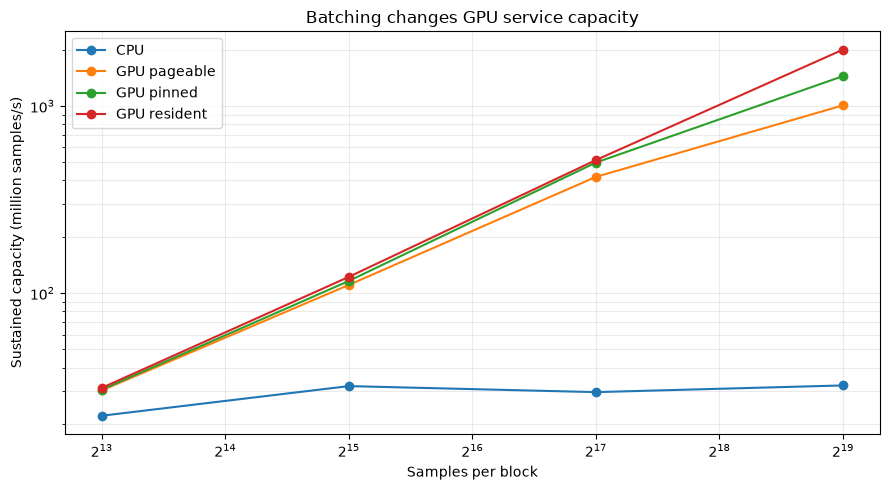

In [6]:
labels = {
    "cpu": "CPU",
    "gpu_pageable": "GPU pageable",
    "gpu_pinned": "GPU pinned",
    "gpu_resident": "GPU resident",
}
fig, ax = plt.subplots(figsize=(9, 5))
for implementation, rows in capacity.groupby("implementation"):
    rows = rows.sort_values("block_size")
    ax.plot(rows["block_size"], rows["sustained_msps"], marker="o", label=labels[implementation])
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Samples per block")
ax.set_ylabel("Sustained capacity (million samples/s)")
ax.set_title("Batching changes GPU service capacity")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
confirmation_table = confirmed[[
    "block_size",
    "implementation",
    "sample_rate_msps",
    "block_period_ms",
    "median_service_ms",
    "p99_latency_ms",
    "deadline_miss_fraction",
    "drop_fraction",
    "max_queue_depth",
]].copy()
confirmation_table["implementation"] = confirmation_table["implementation"].map(labels)
confirmation_table["deadline_miss_percent"] = 100 * confirmation_table.pop("deadline_miss_fraction")
confirmation_table["drop_percent"] = 100 * confirmation_table.pop("drop_fraction")
confirmation_table.round({
    "block_period_ms": 3,
    "median_service_ms": 3,
    "p99_latency_ms": 3,
    "deadline_miss_percent": 3,
    "drop_percent": 3,
})

,block_size,implementation,sample_rate_msps,block_period_ms,median_service_ms,p99_latency_ms,max_queue_depth,deadline_miss_percent,drop_percent
0,32768,CPU,20.0,1.638,1.154,1.511,1,0.000,0.000
1,32768,CPU,30.0,1.092,0.970,2.650,5,44.343,0.000
2,32768,CPU,40.0,0.819,0.982,10.303,8,100.000,18.922
3,32768,GPU pinned,40.0,0.819,0.333,0.702,2,0.016,0.000
4,32768,GPU pinned,80.0,0.410,0.295,0.369,2,0.279,0.000
5,32768,GPU pinned,110.0,0.298,0.262,0.333,5,50.503,0.000
6,131072,CPU,20.0,6.554,4.688,5.591,1,0.000,0.000
7,131072,CPU,30.0,4.369,4.407,41.615,8,100.000,1.048
8,131072,CPU,40.0,3.277,4.332,42.370,8,100.000,25.164
9,131072,GPU pinned,100.0,1.311,0.432,0.817,1,0.000,0.000


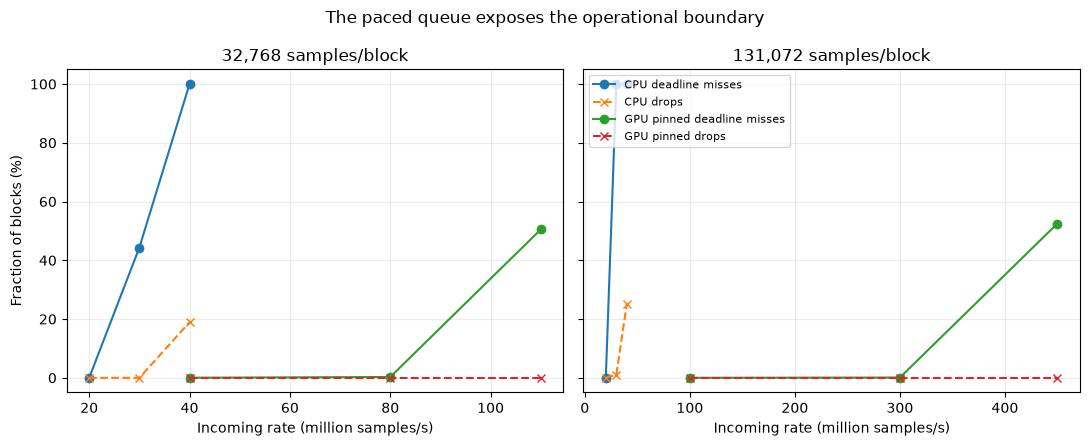

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, block_size in zip(axes, [32_768, 131_072]):
    subset = confirmed[confirmed["block_size"] == block_size]
    for implementation, rows in subset.groupby("implementation"):
        rows = rows.sort_values("sample_rate_msps")
        ax.plot(
            rows["sample_rate_msps"],
            100 * rows["deadline_miss_fraction"],
            marker="o",
            label=f"{labels[implementation]} deadline misses",
        )
        ax.plot(
            rows["sample_rate_msps"],
            100 * rows["drop_fraction"],
            marker="x",
            linestyle="--",
            label=f"{labels[implementation]} drops",
        )
    ax.set_title(f"{block_size:,} samples/block")
    ax.set_xlabel("Incoming rate (million samples/s)")
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel("Fraction of blocks (%)")
axes[1].legend(loc="upper left", fontsize=8)
fig.suptitle("The paced queue exposes the operational boundary")
plt.tight_layout()
plt.show()

## What the queue adds to the speedup result

At 131,072 samples per block, the five-second confirmations put the CPU's tested clean/failed bracket between 20 and 30 million samples/s. At 30 million, its median service time was almost exactly the 4.369 ms block period, but queueing pushed every completion past its deadline and eventually produced drops.

The pinned GPU stayed below 0.1% misses with no drops at 300 million samples/s. At 450 million, median service time was still shorter than the nominal period, yet scheduler and queue latency caused roughly half the blocks to finish late. Capacity headroom and latency headroom are different budgets.

This is soft-real-time evidence from a synthetic replay on a general-purpose Ubuntu host. A radio deployment still has to include device ingress, driver behavior, buffer ownership, CPU isolation, real-time scheduling, and a loss policy. The useful conclusion is narrower: once the CPU's sustained service rate falls below the arrival rate, acceleration is no longer a convenience. Something must changeâ€”GPU placement, block size, algorithm, hardware, or accepted lossâ€”because the source will not slow down for the FFT.